# Notebook 1 — Dataset Creation

**Objective.** Turn many raw recording sessions into **one consolidated,
machine-learning-ready dataset** — fully automatically.

This notebook now covers the *entire* path from raw session folders to the final
CSV. It first runs the **Ground Truth Classifier** on every session to (re)generate
the per-session labelled CSV, then collects and merges those CSVs.

### Complete workflow
1. **Scan** the input directory for all session folders.
2. **Run the Ground Truth Classifier** for every session → produces
   `labelled_dataset.csv` inside each session folder.
3. **Verify** a labelled CSV was successfully created for each session.
4. **Load** all labelled CSVs.
5. **Merge** them into one consolidated dataset.
6. **Save** the combined dataset as a single CSV.

Each session folder is expected to contain at least the raw `events.jsonl`
(and optionally `video.mp4` / `fer_events.jsonl`) plus `session_meta.json`:

```
sessions/
├── 2025-11-26_14-30_proband_01/
│   ├── events.jsonl
│   ├── session_meta.json
│   ├── video.mp4              (optional)
│   └── labelled_dataset.csv   ← (re)generated in step 2
└── ...
```


## 1  Imports & Configuration

`SESSIONS_ROOT` holds all session sub-folders. `CLASSIFIER_NB` is the Ground
Truth Classifier notebook that is executed once per session.
`REGENERATE_LABELS` controls whether existing labelled CSVs are recomputed or
reused.


In [ ]:
import json
import os
import re
import subprocess
import sys
from pathlib import Path

import pandas as pd

# ── Configuration ────────────────────────────────────────────────
SESSIONS_ROOT   = Path("./sessions")                       # all session sub-folders
CLASSIFIER_NB   = Path("./02_ground_truth_classifier.ipynb")  # ground-truth classifier
CSV_NAME        = "labelled_dataset.csv"                   # per-session output we collect
OUTPUT_CSV      = Path("./consolidated_dataset.csv")       # final consolidated dataset

# If True, re-run the classifier for every session even if a labelled CSV exists.
# If False, sessions that already have a labelled CSV are skipped (faster re-runs).
REGENERATE_LABELS = True

# Drop windows the labeller could not classify (label == "excluded").
DROP_EXCLUDED = True

print(f"Sessions root      : {SESSIONS_ROOT.resolve()}")
print(f"Classifier notebook: {CLASSIFIER_NB.resolve()}")
print(f"Collecting         : {CSV_NAME}")
print(f"Output             : {OUTPUT_CSV.resolve()}")
print(f"Regenerate labels  : {REGENERATE_LABELS}")


Sessions root      : C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\notebooks\sessions
Classifier notebook: C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\notebooks\03_ground_truth_classifier.ipynb
Output             : C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\notebooks\consolidated_dataset.csv
Regenerate labels  : True


## 2  Step 1 — Scan for Session Folders

A session is any sub-folder of `SESSIONS_ROOT` that contains a
`session_meta.json` (written by the recording notebook). We discover them
automatically so new recordings are picked up just by dropping their folder in.


In [2]:
def scan_session_folders(root: Path) -> list[Path]:
    """Return every session folder under `root` that has a session_meta.json."""
    if not root.exists():
        raise FileNotFoundError(f"Sessions root not found: {root.resolve()}")
    folders = sorted(p.parent for p in root.glob("*/session_meta.json"))
    return folders


session_folders = scan_session_folders(SESSIONS_ROOT)
print(f"Found {len(session_folders)} session folder(s):\n")
for f in session_folders:
    has_csv = (f / CSV_NAME).exists()
    print(f"  {f.name:<34}  labelled_csv={'yes' if has_csv else 'no'}")

if not session_folders:
    raise RuntimeError(
        f"No session folders found under {SESSIONS_ROOT.resolve()}.\n"
        "Each session must contain a session_meta.json produced by the recorder."
    )


Found 15 session folder(s):

  2026-07-06_16-11_proband_01         labelled_csv=yes
  2026-07-06_16-25_proband_01         labelled_csv=yes
  2026-07-06_16-39_proband_01         labelled_csv=yes
  2026-07-06_16-54_proband_01         labelled_csv=yes
  2026-07-06_17-20_proband_01         labelled_csv=yes
  2026-07-06_17-33_proband_01         labelled_csv=yes
  2026-07-06_17-49_proband_01         labelled_csv=yes
  2026-07-06_18-03_proband_01         labelled_csv=yes
  2026-07-06_18-17_proband_01         labelled_csv=yes
  2026-07-06_18-32_proband_01         labelled_csv=yes
  2026-07-06_18-48_proband_01         labelled_csv=yes
  2026-07-06_19-02_proband_01         labelled_csv=yes
  2026-07-06_19-14_proband_01         labelled_csv=yes
  2026-07-06_19-27_proband_01         labelled_csv=yes
  2026-07-06_19-51_proband_01         labelled_csv=yes


## 3  Step 2 — Run the Ground Truth Classifier per Session

### Purpose of this stage
The raw `events.jsonl` from a recording holds only *sensor streams* — heartbeats,
plant voltage, video frames. It has **no emotion labels**. The Ground Truth
Classifier converts each session's raw data into a labelled table: it computes
HRV windows, runs facial-expression validation, fuses them into a 3-class
emotion label, and adds the plant-bioelectric features. That per-session
`labelled_dataset.csv` is the unit we later merge.

### How it is executed
The classifier is a notebook. We run it **headless, once per session**, with
`jupyter nbconvert --execute`. The session to process is passed via the
environment variable `SESSION_DIR_OVERRIDE`, which the classifier reads in its
configuration cell. This keeps the classifier as the single source of truth for
the labelling logic — this notebook never duplicates it.

A per-session timeout guards against a hanging run. Failures are collected and
reported rather than aborting the whole batch.


In [3]:
def run_classifier_for_session(session_dir: Path, classifier_nb: Path,
                               timeout_s: int = 1800) -> tuple[bool, str]:
    """Execute the classifier notebook headless for one session.

    The session is selected via the SESSION_DIR_OVERRIDE environment variable,
    which the classifier reads in its config cell. Returns (success, message).
    """
    env = dict(os.environ)
    env["SESSION_DIR_OVERRIDE"] = str(session_dir.resolve())

    cmd = [
        sys.executable, "-m", "jupyter", "nbconvert",
        "--to", "notebook",
        "--execute",
        "--ExecutePreprocessor.timeout=%d" % timeout_s,
        # Write the executed copy next to the session so the run is auditable,
        # and the original classifier notebook is never modified.
        "--output", f"_executed_{session_dir.name}.ipynb",
        "--output-dir", str(session_dir.resolve()),
        str(classifier_nb.resolve()),
    ]
    try:
        proc = subprocess.run(cmd, env=env, capture_output=True, text=True,
                              timeout=timeout_s + 60)
        if proc.returncode != 0:
            # Surface the last lines of stderr for debugging
            tail = "\n".join(proc.stderr.strip().splitlines()[-8:])
            return False, f"nbconvert exit {proc.returncode}:\n{tail}"
        return True, "ok"
    except subprocess.TimeoutExpired:
        return False, f"timed out after {timeout_s}s"
    except FileNotFoundError as e:
        return False, f"jupyter/nbconvert not available: {e}"


# Run the classifier for every session
results = []
for sdir in session_folders:
    csv_path = sdir / CSV_NAME
    if csv_path.exists() and not REGENERATE_LABELS:
        results.append((sdir.name, "skipped (csv exists)", True))
        print(f"  {sdir.name:<34} skipped — labelled CSV already present")
        continue

    print(f"  {sdir.name:<34} running classifier ...", flush=True)
    ok, msg = run_classifier_for_session(sdir, CLASSIFIER_NB)
    results.append((sdir.name, msg, ok))
    print(f"  {sdir.name:<34} {'✓ done' if ok else '✗ FAILED: ' + msg}")

n_ok = sum(1 for _, _, ok in results if ok)
print(f"\nClassifier stage complete: {n_ok}/{len(results)} sessions succeeded.")


  2026-07-06_16-11_proband_01        running classifier ...
  2026-07-06_16-11_proband_01        ✓ done
  2026-07-06_16-25_proband_01        running classifier ...
  2026-07-06_16-25_proband_01        ✓ done
  2026-07-06_16-39_proband_01        running classifier ...
  2026-07-06_16-39_proband_01        ✓ done
  2026-07-06_16-54_proband_01        running classifier ...
  2026-07-06_16-54_proband_01        ✓ done
  2026-07-06_17-20_proband_01        running classifier ...
  2026-07-06_17-20_proband_01        ✓ done
  2026-07-06_17-33_proband_01        running classifier ...
  2026-07-06_17-33_proband_01        ✓ done
  2026-07-06_17-49_proband_01        running classifier ...
  2026-07-06_17-49_proband_01        ✓ done
  2026-07-06_18-03_proband_01        running classifier ...
  2026-07-06_18-03_proband_01        ✓ done
  2026-07-06_18-17_proband_01        running classifier ...
  2026-07-06_18-17_proband_01        ✓ done
  2026-07-06_18-32_proband_01        running classifier ...
  20

## 4  Step 3 — Verify Labelled CSVs Exist

Before merging we confirm that every session now has a readable
`labelled_dataset.csv` with at least one row. Sessions that failed the
classifier stage are reported and excluded from the merge so one bad recording
cannot abort the whole dataset build.


In [4]:
verified, missing = [], []
for sdir in session_folders:
    csv_path = sdir / CSV_NAME
    if csv_path.exists():
        try:
            n = len(pd.read_csv(csv_path))
            if n > 0:
                verified.append(sdir)
                print(f"  ✓ {sdir.name:<34} {n} labelled windows")
            else:
                missing.append((sdir.name, "empty CSV"))
                print(f"  ✗ {sdir.name:<34} CSV is empty")
        except Exception as e:
            missing.append((sdir.name, f"unreadable: {e}"))
            print(f"  ✗ {sdir.name:<34} unreadable CSV")
    else:
        missing.append((sdir.name, "no CSV produced"))
        print(f"  ✗ {sdir.name:<34} no labelled CSV produced")

print(f"\n{len(verified)}/{len(session_folders)} sessions have a valid labelled CSV.")
if missing:
    print("Sessions excluded from the merge:")
    for name, why in missing:
        print(f"   - {name}: {why}")
if not verified:
    raise RuntimeError("No valid labelled CSVs — cannot build a dataset.")


  ✓ 2026-07-06_16-11_proband_01        114 labelled windows
  ✓ 2026-07-06_16-25_proband_01        113 labelled windows
  ✓ 2026-07-06_16-39_proband_01        114 labelled windows
  ✓ 2026-07-06_16-54_proband_01        114 labelled windows
  ✓ 2026-07-06_17-20_proband_01        114 labelled windows
  ✓ 2026-07-06_17-33_proband_01        112 labelled windows
  ✓ 2026-07-06_17-49_proband_01        113 labelled windows
  ✓ 2026-07-06_18-03_proband_01        114 labelled windows
  ✓ 2026-07-06_18-17_proband_01        113 labelled windows
  ✓ 2026-07-06_18-32_proband_01        114 labelled windows
  ✓ 2026-07-06_18-48_proband_01        114 labelled windows
  ✓ 2026-07-06_19-02_proband_01        114 labelled windows
  ✓ 2026-07-06_19-14_proband_01        114 labelled windows
  ✓ 2026-07-06_19-27_proband_01        114 labelled windows
  ✓ 2026-07-06_19-51_proband_01        113 labelled windows

15/15 sessions have a valid labelled CSV.


## 5  Step 4 — Load All Labelled CSVs

For every verified session we load its labelled CSV and **prepend provenance
columns** (`session_id`, `proband_id`, `session_date`). Provenance lets us trace
each row to its source and — crucially — perform participant-aware train/test
splits later, preventing data leakage in the ML notebook.


In [5]:
def parse_provenance(session_dir: Path) -> dict:
    """Recover session_id / proband_id / session_date from meta or folder name."""
    session_id = session_dir.name
    proband_id, session_date = None, None
    meta_path = session_dir / "session_meta.json"
    if meta_path.exists():
        try:
            meta = json.loads(meta_path.read_text())
            proband_id  = meta.get("proband_id")
            recorded_at = meta.get("recorded_at")
            if recorded_at:
                session_date = recorded_at[:10]
        except Exception:
            pass
    if proband_id is None or session_date is None:
        m = re.match(r"(\d{4}-\d{2}-\d{2})_(\d{2}-\d{2})_(.+)", session_id)
        if m:
            session_date = session_date or m.group(1)
            proband_id   = proband_id   or m.group(3)
    return {"session_id": session_id,
            "proband_id": proband_id or "unknown",
            "session_date": session_date or "unknown"}


def load_session_csv(session_dir: Path) -> pd.DataFrame:
    df = pd.read_csv(session_dir / CSV_NAME)
    prov = parse_provenance(session_dir)
    df.insert(0, "session_date", prov["session_date"])
    df.insert(0, "proband_id",   prov["proband_id"])
    df.insert(0, "session_id",   prov["session_id"])
    return df


frames, summary = [], []
for sdir in verified:
    df = load_session_csv(sdir)
    frames.append(df)
    summary.append({"session_id": sdir.name,
                    "participant": parse_provenance(sdir)["proband_id"],
                    "rows": len(df), "columns": df.shape[1]})

summary_df = pd.DataFrame(summary)
print("Per-session row counts:")
print(summary_df.to_string(index=False))
print(f"\nTotal rows across all sessions: {summary_df['rows'].sum()}")


Per-session row counts:
                 session_id participant  rows  columns
2026-07-06_16-11_proband_01  proband_01   114       42
2026-07-06_16-25_proband_01  proband_01   113       42
2026-07-06_16-39_proband_01  proband_01   114       42
2026-07-06_16-54_proband_01  proband_01   114       42
2026-07-06_17-20_proband_01  proband_01   114       42
2026-07-06_17-33_proband_01  proband_01   112       42
2026-07-06_17-49_proband_01  proband_01   113       42
2026-07-06_18-03_proband_01  proband_01   114       42
2026-07-06_18-17_proband_01  proband_01   113       42
2026-07-06_18-32_proband_01  proband_01   114       42
2026-07-06_18-48_proband_01  proband_01   114       42
2026-07-06_19-02_proband_01  proband_01   114       42
2026-07-06_19-14_proband_01  proband_01   114       42
2026-07-06_19-27_proband_01  proband_01   114       42
2026-07-06_19-51_proband_01  proband_01   113       42

Total rows across all sessions: 1704


## 6  Step 5 — Schema Check & Merge

We verify all sessions share the same columns (a mismatch would indicate
different pipeline versions), then concatenate row-wise. Each row is an
independent labelled window, so `pd.concat` (stacking observations) is the
correct operation — not a key-based join.


In [6]:
# Schema consistency
col_sets = [set(f.columns) for f in frames]
reference = col_sets[0]
if all(cs == reference for cs in col_sets):
    print(f"✓ All {len(frames)} sessions share an identical schema "
          f"({len(reference)} columns).")
else:
    union = set().union(*col_sets)
    print("⚠ Schema mismatch — columns differing across sessions:")
    for i, cs in enumerate(col_sets):
        diff = union - cs
        if diff:
            print(f"  {summary[i]['session_id']}: missing {sorted(diff)}")
    print("Merging on the intersection of columns.")

# Merge
dataset = pd.concat(frames, ignore_index=True, sort=False)
print(f"\nConsolidated dataset: {dataset.shape[0]} rows × {dataset.shape[1]} columns")


✓ All 15 sessions share an identical schema (42 columns).

Consolidated dataset: 1704 rows × 42 columns


## 7  Integrity Checks & Cleaning

Final checks: overall and per-participant label distribution, duplicate-window
detection, and optional removal of `excluded` windows (which carry no usable
target).


In [7]:
print("Overall label distribution:")
print(dataset["label"].value_counts(dropna=False).to_string())

print("\nLabel distribution per participant:")
print(pd.crosstab(dataset["proband_id"], dataset["label"]).to_string())

# Duplicate window guard
if {"session_id", "win_start_ms"}.issubset(dataset.columns):
    dup = dataset.duplicated(subset=["session_id", "win_start_ms"]).sum()
    print(f"\nDuplicate (session_id, win_start_ms) rows: {dup}")
    if dup:
        dataset = dataset.drop_duplicates(subset=["session_id", "win_start_ms"])
        print("  Dropped exact duplicates.")

# Drop excluded windows
if DROP_EXCLUDED and "label" in dataset.columns:
    before = len(dataset)
    dataset = dataset[dataset["label"] != "excluded"].reset_index(drop=True)
    print(f"\nDropped {before - len(dataset)} 'excluded' windows "
          f"({len(dataset)} usable rows remain).")


Overall label distribution:
label
neutral     754
positiv     483
negativ     453
excluded     14

Label distribution per participant:
label       excluded  negativ  neutral  positiv
proband_id                                     
proband_01        14      453      754      483

Duplicate (session_id, win_start_ms) rows: 0



Dropped 14 'excluded' windows (1690 usable rows remain).


## 8  Step 6 — Save the Consolidated Dataset

The final table is written to a single CSV — the only input required by
**Notebook 2 (Machine Learning Pipeline)**.


In [8]:
dataset.to_csv(OUTPUT_CSV, index=False)
print(f"✓ Saved consolidated dataset to: {OUTPUT_CSV.resolve()}")
print(f"  {dataset.shape[0]} rows × {dataset.shape[1]} columns")
print(f"  Participants: {dataset['proband_id'].nunique()}")
print(f"  Sessions    : {dataset['session_id'].nunique()}")
print(f"\nClass balance (usable rows):")
print(dataset["label"].value_counts(normalize=True).mul(100).round(1)
      .astype(str).add(" %").to_string())
dataset.head()


✓ Saved consolidated dataset to: C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\notebooks\consolidated_dataset.csv
  1690 rows × 42 columns
  Participants: 1
  Sessions    : 15

Class balance (usable rows):
label
neutral    44.6 %
positiv    28.6 %
negativ    26.8 %


,session_id,proband_id,session_date,win_start_ms,win_end_ms,label,agreement,label_confidence,reason,rmssd,...,bp_0_1,bp_1_5,bp_5_15,bp_15_30,bp_30_50,total_power,plant_quality,plant_dead_flag,plant_suspect_flag,co2_mean
0,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347080792,1783347110792,neutral,hrv_only,0.293,rz=-0.31 hz=+1.04 fer=neutral,35.893656,...,0.000068,0.000018,0.000015,0.000010,0.000051,0.000162,ok,False,False,574.3
1,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347085792,1783347115792,neutral,hrv_only,0.243,rz=+0.19 hz=+0.88 fer=neutral,38.292757,...,0.000104,0.000017,0.000016,0.000011,0.000056,0.000204,ok,False,False,575.0
2,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347090792,1783347120792,neutral,hrv_only,0.278,rz=+0.37 hz=+0.89 fer=neutral,39.172635,...,0.000127,0.000017,0.000015,0.000011,0.000055,0.000225,ok,False,False,576.1
3,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347095792,1783347125792,positiv,hrv_only,0.298,rz=+0.65 hz=+0.73 fer=neutral,40.519444,...,0.000133,0.000014,0.000014,0.000011,0.000058,0.000229,ok,False,False,577.8
4,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347100792,1783347130792,positiv,hrv_only,0.282,rz=+1.09 hz=+0.19 fer=neutral,42.680382,...,0.000141,0.000012,0.000013,0.000010,0.000053,0.000228,ok,False,False,579.6


## 9  All Sessions' Labels, Side by Side

Two complementary views of the same labelled data:

- **Timeline (top):** one horizontal row per session, colored by label with
  bar opacity encoding `label_confidence` — lets you compare *when within a
  session* each class occurs and whether patterns repeat across sessions.
- **Class-balance bars (bottom):** the same sessions' label proportions as
  stacked bars — easier to compare *how much* of each class each session got.

This is purely a visualization addition — it does not change how labels are
derived (that logic lives entirely in `03_ground_truth_classifier.ipynb` and
is untouched) nor the merge/cleaning steps above.


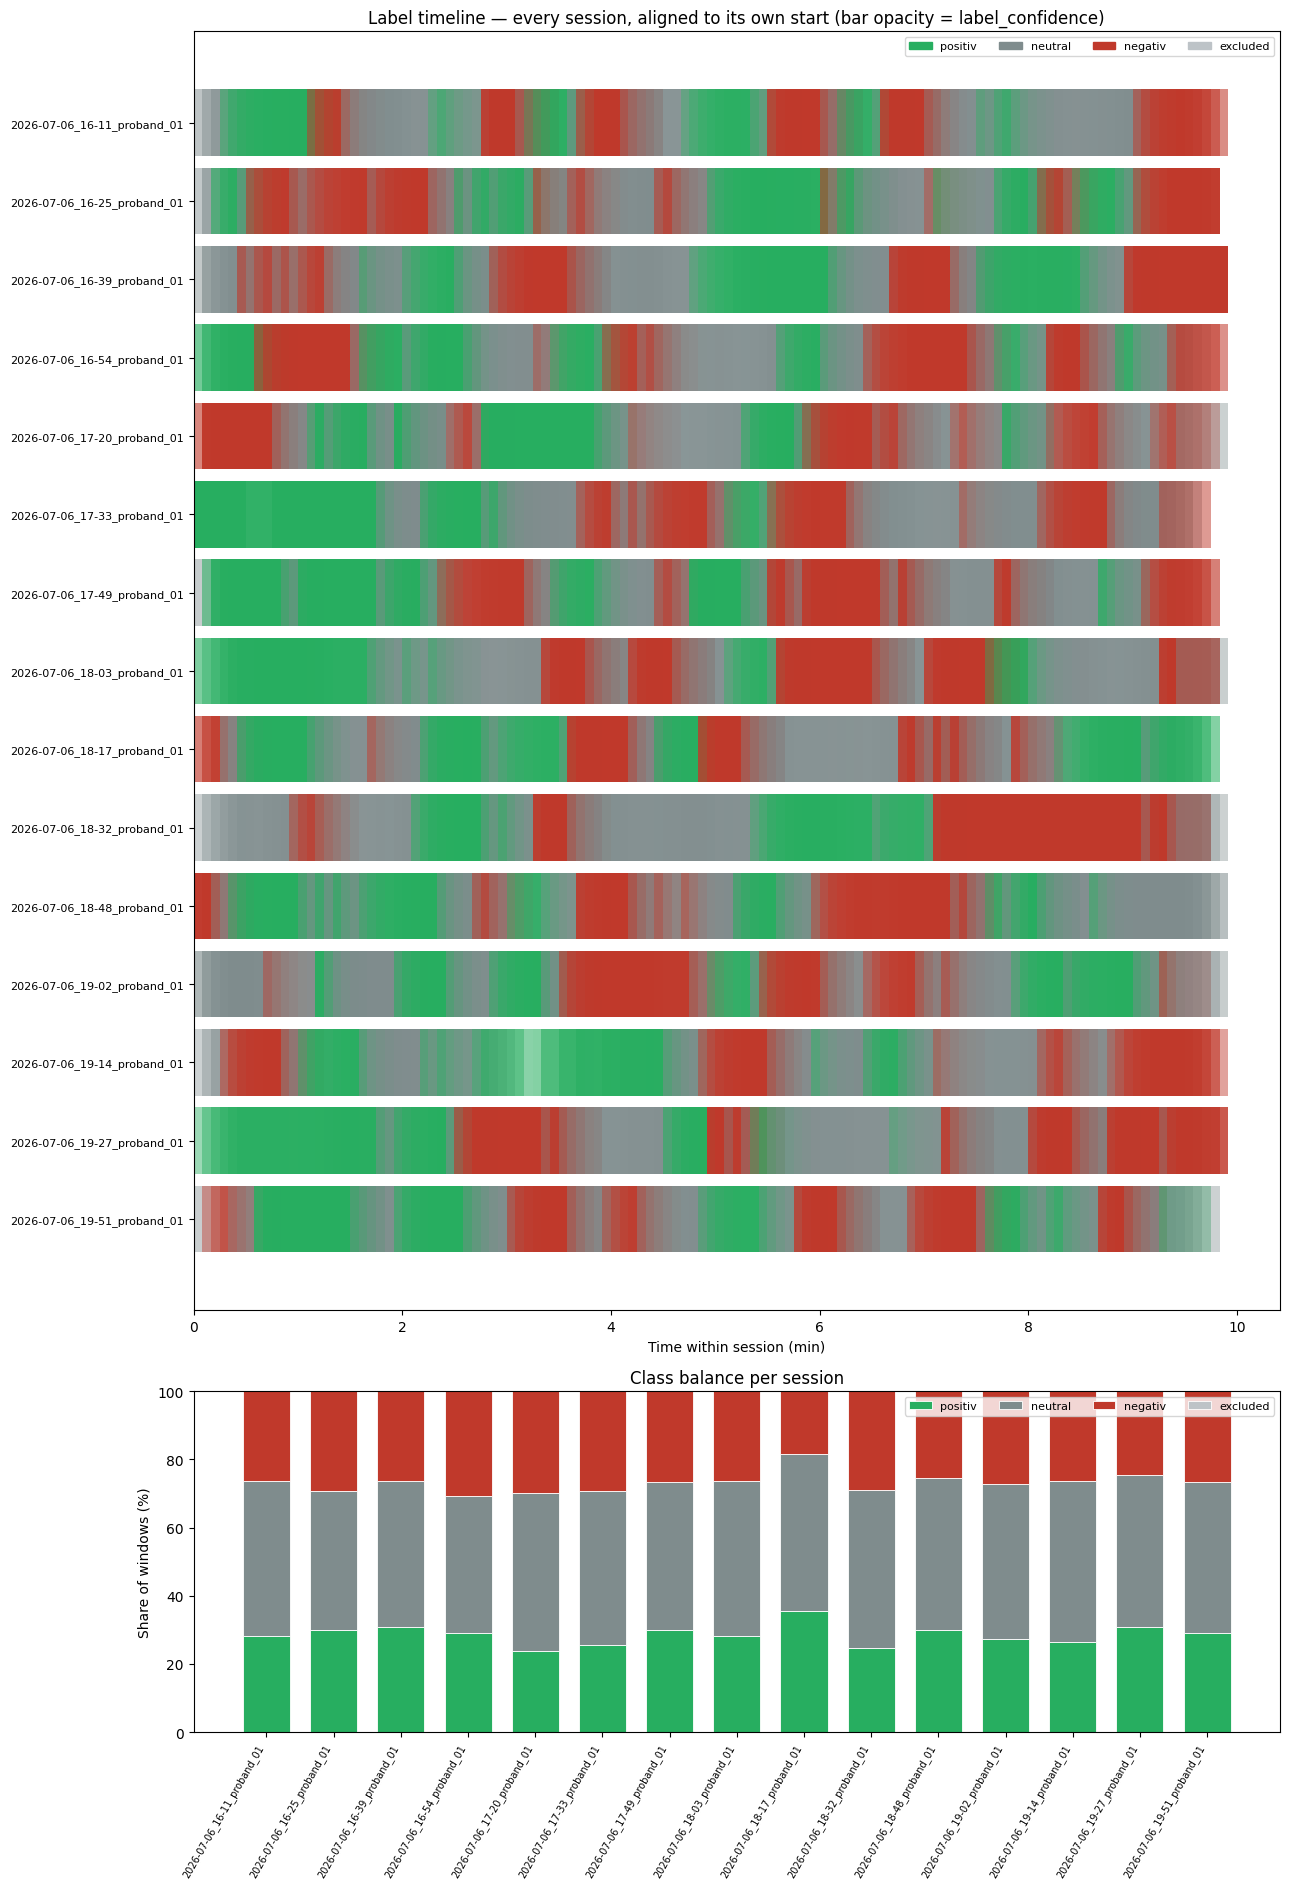

In [9]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Fixed categorical colors — same convention used throughout this project,
# so the same color always means the same label in every notebook.
LABEL_COLOR = {"positiv": "#27ae60", "neutral": "#7f8c8d",
               "negativ": "#c0392b", "excluded": "#bdc3c7"}
LABEL_ORDER = ["positiv", "neutral", "negativ", "excluded"]

sess_order = sorted(dataset["session_id"].unique())
n_sess = len(sess_order)

fig, (ax_tl, ax_bar) = plt.subplots(
    2, 1, figsize=(13, 1.0 * n_sess + 4), gridspec_kw={"height_ratios": [n_sess, 4]}
)

# -- Top: multi-row timeline -----------------------------------------
for row_i, sid in enumerate(sess_order):
    sub = dataset[dataset["session_id"] == sid].sort_values("win_start_ms")
    t0 = sub["win_start_ms"].min()
    for _, r in sub.iterrows():
        t_start_min = (r["win_start_ms"] - t0) / 60_000
        conf = r["label_confidence"] if pd.notna(r["label_confidence"]) else 0.0
        width_min = 30 / 60  # WIN_S = 30s (must match the classifier's window length)
        ax_tl.barh(row_i, width_min, left=t_start_min, height=0.85,
                   color=LABEL_COLOR.get(r["label"], "#bdc3c7"),
                   alpha=0.3 + 0.7 * conf, edgecolor="none")

ax_tl.set_yticks(range(n_sess))
ax_tl.set_yticklabels(sess_order, fontsize=8)
ax_tl.set_xlabel("Time within session (min)")
ax_tl.set_title("Label timeline — every session, aligned to its own start "
                "(bar opacity = label_confidence)")
ax_tl.invert_yaxis()
patches = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLOR.items()]
ax_tl.legend(handles=patches, loc="upper right", fontsize=8, ncol=4)

# -- Bottom: per-session class-balance stacked bars -------------------
counts = (dataset.groupby(["session_id", "label"]).size()
          .unstack(fill_value=0).reindex(index=sess_order, columns=LABEL_ORDER, fill_value=0))
props = counts.div(counts.sum(axis=1), axis=0) * 100

bottom = np.zeros(n_sess)
x = np.arange(n_sess)
for lab in LABEL_ORDER:
    ax_bar.bar(x, props[lab].values, bottom=bottom, color=LABEL_COLOR[lab],
              label=lab, width=0.7, edgecolor="white", linewidth=0.6)
    bottom += props[lab].values

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(sess_order, rotation=60, ha="right", fontsize=7)
ax_bar.set_ylabel("Share of windows (%)")
ax_bar.set_title("Class balance per session")
ax_bar.set_ylim(0, 100)
ax_bar.legend(loc="upper right", fontsize=8, ncol=4)

plt.tight_layout()
plt.show()


---

**Next step:** open **Notebook 2 — Machine Learning Pipeline**, which loads
`consolidated_dataset.csv` and trains and compares three classifiers.
